# Notebook 12 | Law of Large Numbers

In [1]:
from foundations_of_probability_and_statistics.cars.horsepower_moments import conditional_horsepower_mean
from foundations_of_probability_and_statistics.cars.horsepower_moments import conditional_horsepower_variance
from foundations_of_probability_and_statistics.cars.sample_from_car_distribution import sample_from_car_distribution

import pandas as pd

# show all rows of data frames and series per default
pd.set_option("display.max_rows", None)

## The weak and strong laws together: averages settle down

Fix a brand $b$ and sample $X = (H \mid B = b)$ with mean $\mu_b = \mathbb{E}[H \mid B = b]$ (notebook 10) and variance $\sigma_b^2 = \mathrm{Var}(H \mid B = b)$ (notebook 11). Both laws say the sample mean $\bar{X}_n = \frac{1}{n} \sum_{i=1}^n X_i$ converges to $\mu_b$, but they promise different strengths. The weak law gives convergence in probability, quantitatively through Chebyshev's inequality:

$$P(|\bar{X}_n - \mu_b| \geq \varepsilon) \leq \frac{\sigma_b^2}{n \, \varepsilon^2} \to 0.$$

The strong law upgrades this to convergence with probability one: apart from a null set of freak sequences, every realized running average eventually stays close. Weak tells us how fast deviations become unlikely; strong tells us almost every path settles. Reach for Chebyshev whenever a finite-$n$ guarantee is needed without distributional assumptions.

## Derivation

1. Fix $X = (H \mid B = \text{VW})$ with $\mu = 150$ and $\sigma^2 = 4500$.
2. The sample mean averages $n$ independent copies, so $\mathrm{Var}(\bar{X}_n) = \sigma^2 / n$ -- averaging shrinks variance linearly.
3. Apply Chebyshev's inequality to $\bar{X}_n$: $P(|\bar{X}_n - 150| \geq 10) \leq 4500 / (100 \, n)$.
4. The bound vanishes as $n \to \infty$ (weak law); the strong law upgrades convergence to almost sure without changing the bound.

The characteristic mistake is reading the bound as an observed frequency: it is a worst-case ceiling valid for any distribution with this variance, usually far looser than what the trace actually does.

## Worked example (by hand)

Chebyshev bound $P(|\bar{X}_n - 150| \geq 10) \leq 4500 / (100 \, n)$ for $X = (H \mid B = \text{VW})$:

$$n = 100: \quad 4500 / 10000 = 0.45,$$
$$n = 10^4: \quad 4500 / 10^6 = 0.0045,$$
$$n = 10^6: \quad 4500 / 10^8 = 0.000045.$$

Each factor of 100 in sample size buys two decimals of guaranteed rarity -- the $1/n$ rate made concrete. At $n = 100$ the bound is nearly vacuous (0.45); at $n = 10^6$ deviations of 10 hp are essentially ruled out. Reality converges faster than Chebyshev promises; the bound is the price of assuming nothing but a variance.

In [2]:
import math

# Chebyshev bound p(|Xbar_n - 150| >= 10) <= 4500 / (100 n) for X = (H | B = VW)
bound = {100: 4500 / (100 * 100), 10_000: 4500 / (100 * 10_000), 1_000_000: 4500 / (100 * 1_000_000)}
assert math.isclose(bound[100], 0.45)
assert math.isclose(bound[10_000], 0.0045)
assert math.isclose(bound[1_000_000], 0.000045)
assert math.isclose(conditional_horsepower_mean("VW"), 150.0)
assert math.isclose(conditional_horsepower_variance("VW"), 4500.0)
bound

{100: 0.45, 10000: 0.0045, 1000000: 4.5e-05}

## Generalization

One sample of 1,000,000 cars: the running per-brand mean $\bar{X}_n^{(b)}$ (LLN trace) collapses onto $\mathbb{E}[H \mid B = b]$, with the dotted level lines $\mu_b \pm 10$ marking the Chebyshev tolerance band -- an honestly labeled visual anchor, not a confidence interval. Watch the traces enter the band early and never leave: that is the strong law at work, while the bound only quantified the weak one. Notebook 13 asks about the shape of the remaining fluctuations.

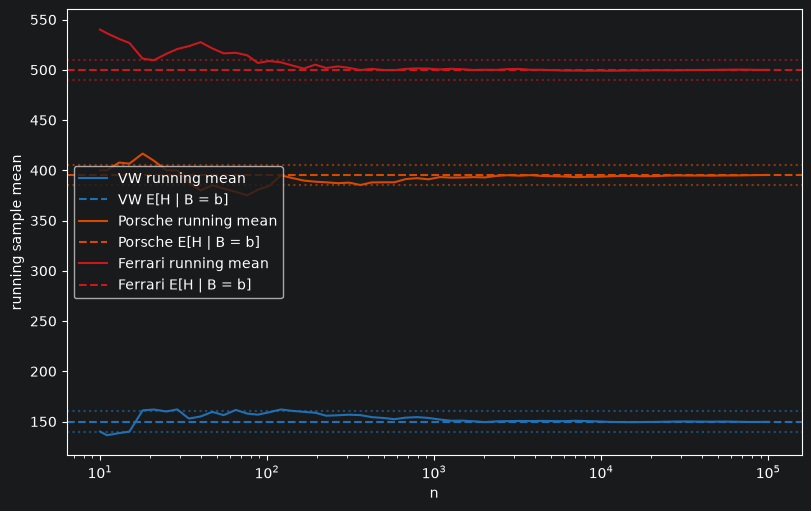

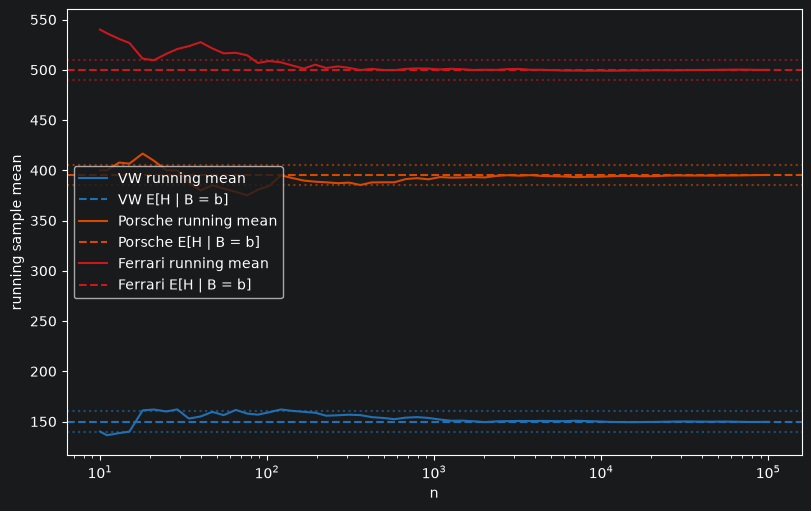

In [3]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

cars = sample_from_car_distribution(n_cars=1_000_000, random_state=42)

# running per-brand means with the mu_b +/- 10 Chebyshev tolerance band
figure, ax = plt.subplots(figsize=(8.0, 5.0), dpi=100, layout="constrained")
for brand, cmap_name in [("VW", "Blues"), ("Porsche", "Oranges"), ("Ferrari", "Reds")]:
    values = cars[cars["brand"] == brand]["horsepower"].to_numpy(dtype=float)
    grid = np.unique(np.logspace(1, int(np.log10(len(values))), num=60, dtype=int))
    grid = grid[grid <= len(values)]
    trace = np.cumsum(values)[grid - 1] / grid
    color = matplotlib.colormaps[cmap_name](0.75)
    mu = conditional_horsepower_mean(brand)
    ax.plot(grid, trace, color=color, label=f"{brand} running mean")
    ax.axhline(mu, color=color, linestyle="--", label=f"{brand} E[H | B = b]")
    # honestly labeled tolerance band, not a confidence interval
    ax.axhline(mu + 10, color=color, linestyle=":", alpha=0.6)
    ax.axhline(mu - 10, color=color, linestyle=":", alpha=0.6)
ax.set_xscale("log")
ax.set_xlabel("n")
ax.set_ylabel("running sample mean")
ax.legend()
figure

## References

- Blitzstein, J. K., Hwang, J. (2019): "Introduction to Probability", 2nd ed., Chapman & Hall/CRC, chapter "Inequalities and Limit Theorems" (LLN is a named section), https://www.routledge.com/Introduction-to-Probability-Second-Edition/Blitzstein-Hwang/p/book/9781138369917 (free PDF: https://probabilitybook.net/).
- Wasserman, L. (2004): "All of Statistics: A Concise Course in Statistical Inference", Springer Texts in Statistics, chapters "Inequalities" (Chebyshev's inequality) and "Convergence of Random Variables" (LLN), https://doi.org/10.1007/978-0-387-21736-9.
- scipy.stats.rv_discrete, https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.rv_discrete.html.